# Demonstration of function mosaic_datasets()

This notebook demonstrates the functionality of the `mosaic_datasets` function, which allows to create spatial mosaics from multiple `xarray.Dataset` objects, including support for overlapping tiles.

In [1]:
import dask.array as da
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from xcube_resampling import mosaic_datasets

We create large Dask-backed datasets.

In [2]:
tile_size = 4096
chunk_size = 1024

# Spatial resolution
dx = 10
dy = 10

# Global coordinates for a 2 x 2 tile layout.
# y is intentionally decreasing, as in many EO products.
x0 = np.arange(0, tile_size) * dx
x1 = np.arange(tile_size - 256, 2 * tile_size - 256) * dx

y0 = np.arange(2 * tile_size - 256, tile_size - 256, -1) * dy
y1 = np.arange(tile_size, 0, -1) * dy

print(x0)
print(x1)
print(y0)
print(y1)

[    0    10    20 ... 40930 40940 40950]
[38400 38410 38420 ... 79330 79340 79350]
[79360 79350 79340 ... 38430 38420 38410]
[40960 40950 40940 ...    30    20    10]


In [3]:
def make_tile(
    x: np.ndarray,
    y: np.ndarray,
    value: float,
) -> xr.Dataset:
    """Create a large Dask-backed synthetic tile."""

    ny = len(y)
    nx = len(x)

    # No actual data is generated yet.
    data = da.full(
        (ny, nx),
        value,
        dtype=np.float32,
        chunks=(chunk_size, chunk_size),
    )

    # Add a little synthetic spatial variation.
    yy = da.from_array(
        np.arange(ny, dtype=np.float32),
        chunks=chunk_size,
    )[:, None]

    xx = da.from_array(
        np.arange(nx, dtype=np.float32),
        chunks=chunk_size,
    )[None, :]

    data = data + xx * 0.001 + yy * 0.002

    return xr.Dataset(
        {
            "temperature": xr.DataArray(
                data,
                dims=("y", "x"),
                coords={
                    "x": x,
                    "y": y,
                },
                attrs={
                    "units": "K",
                },
            ),
        }
    )

Next, we create overlapping tiles and plot each tile individually.

In [4]:
datasets = [
    make_tile(x0, y0, 100.0),
    make_tile(x1, y0, 200.0),
    make_tile(x0, y1, 300.0),
    make_tile(x1, y1, 400.0),
]

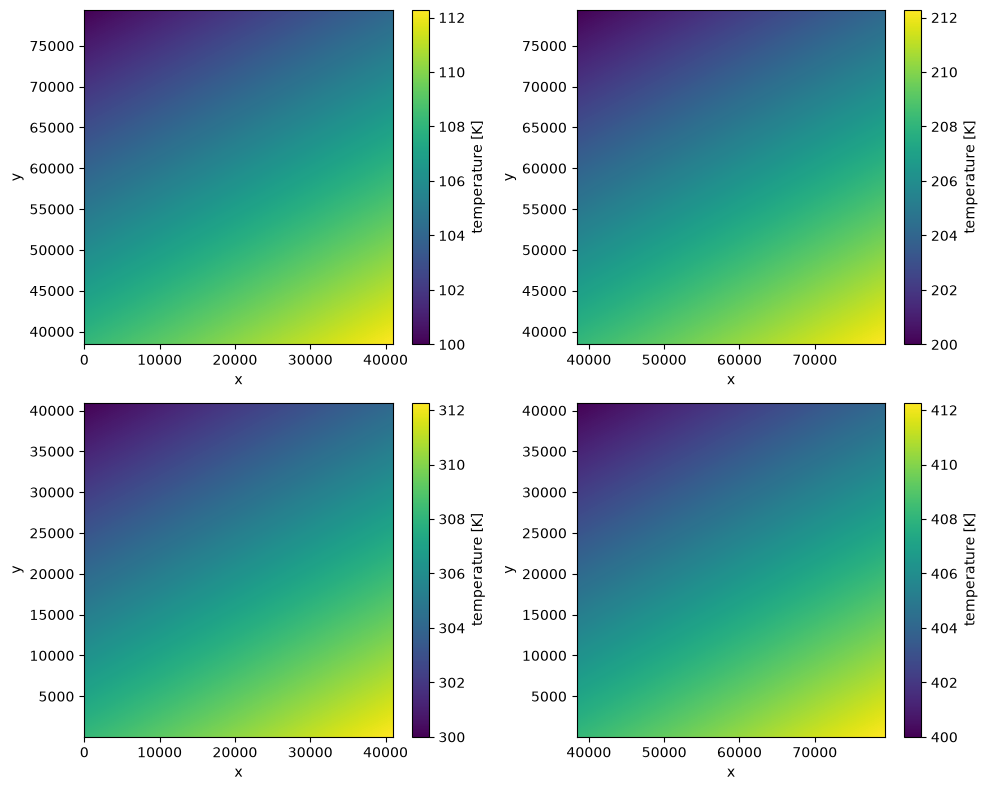

In [5]:
fig, _ax = plt.subplots(2, 2, figsize=(10, 8))
ax = _ax.flatten()
for i, dataset in enumerate(datasets):
    dataset["temperature"][::4, ::4].plot(ax=ax[i])
plt.tight_layout()

Next we can mosaic the tiles and plot the resulting mosaic.

In [6]:
mosaic = mosaic_datasets(
    datasets,
    x_dim="x",
    y_dim="y",
    tile_size=(2048, 2048),
)
mosaic

<xarray.Dataset> Size: 252MB
Dimensions:      (y: 7936, x: 7936)
Coordinates:
  * y            (y) float64 63kB 7.936e+04 7.935e+04 7.934e+04 ... 20.0 10.0
  * x            (x) float64 63kB 0.0 10.0 20.0 ... 7.934e+04 7.935e+04
Data variables:
    temperature  (y, x) float32 252MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>

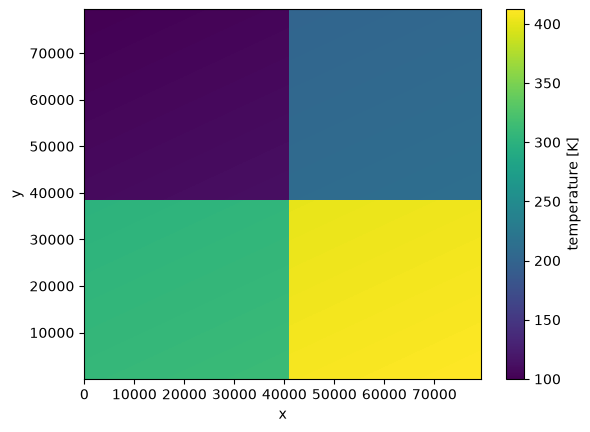

In [7]:
mosaic["temperature"][::8, ::8].plot()